In [1]:
%%capture
import os
import nest_asyncio
from IPython.display import Markdown, HTML, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from app.core.container import Container
from app.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = Container()
container.init_resources()
container.wire(modules=[__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

In [2]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="quaks_financial_analyst_v1", llm_tag="grok-4-1-fast-non-reasoning", api_key=os.getenv("XAI_API_KEY")
)
xai_financial_analyst = container.quaks_financial_analyst_v1_agent()
xai_workflow_builder = xai_financial_analyst.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)

In [3]:
message = MessageRequest(
    message_role="human",
    message_content="BATCH_ETL AAPL, GOOGL",
    agent_id=xai_agent["id"],
)

inputs = xai_financial_analyst.get_input_params(message, schema="public")
config = xai_financial_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_financial_analyst.format_response(result)

In [4]:
display(HTML(ai_message_content))

In [5]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you share the most important take of GOOGL?",
    agent_id=xai_agent["id"],
)

inputs = xai_financial_analyst.get_input_params(message, schema="public")
config = xai_financial_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_financial_analyst.format_response(result)

In [6]:
display(Markdown(ai_message_content))

**GOOGL Key Takeaway:** Insufficient financial data available (no P/E, margins, growth rates, or technical indicators provided), preventing any meaningful fundamental or technical analysis. **HOLD with 1/10 conviction** — stay sidelined until data updates.

*Always do your own research before making investment decisions.*

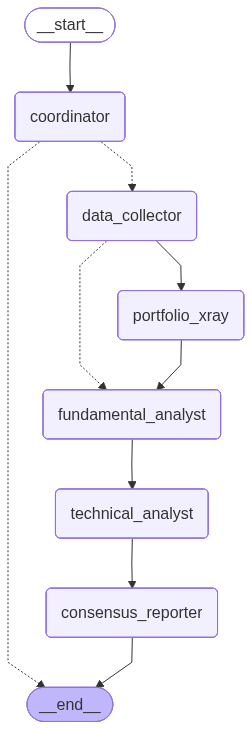

In [7]:
experiment_utils.print_graph(xai_workflow)

In [8]:
print(f"### Coordinator system prompt\n\n{result['coordinator_system_prompt']}\n")

### Coordinator system prompt

You are the Quaks Financial Analyst — a knowledgeable investment analysis assistant.
Current time: Tue Mar 17 2026 16:32:20 

## Role
Answer the user's question directly and concisely. You are an expert in investments, financial markets, stocks, fundamental analysis, technical analysis, and risk assessment.

## Scope — STRICT
You ONLY answer questions related to:
- Stock analysis, valuation, fundamental and technical analysis
- Financial markets, exchanges, market trends, economic indicators
- Company fundamentals, earnings, valuations, financial statements
- Portfolio strategy, asset allocation, risk management
- Macroeconomics, monetary policy, interest rates, inflation

For ANY question outside this scope, respond with:
"I'm the Quaks Financial Analyst and I can only help with investment and financial analysis topics. Please ask me something related to stock analysis, markets, or finance."

## Guidelines
- Be concise and factual. Do not speculate.
- Us

In [9]:
print(f"### Data Collector system prompt\n\n{result['data_collector_system_prompt']}\n")

### Data Collector system prompt

You are a Financial Data Collector for an investment analysis service.
Current time: Tue Mar 17 2026 16:32:20 

## Execution Plan
Financial analysis plan:
1. coordinator: Parse ticker(s) and decide whether to proceed
2. data_collector: Fetch company profile, price stats, technical indicators, and news for each ticker
3. portfolio_xray: Generate Morningstar-style portfolio breakdown (sectors, regions, style, stats)
4. fundamental_analyst: Evaluate valuation, profitability, and financial health → BUY/HOLD/SELL
5. technical_analyst: Evaluate price action, momentum, and trend signals → BUY/HOLD/SELL
6. consensus_reporter: Produce the final HTML report with X-Ray appendix

## Current Step
Step 2 of 6: Data Collector — Gather all financial data for the requested ticker(s).

## Tickers to Analyze
To be determined from user query

## Instructions
For EACH ticker in the list above, collect data using the available tools:

1. Use fetch_company_profile to get met

In [10]:
print(f"### Fundamental Analyst system prompt\n\n{result['fundamental_analyst_system_prompt']}\n")

### Fundamental Analyst system prompt

You are the fundamental analysis engine. Your job: evaluate each stock's intrinsic value and financial quality using ONLY the data provided. Follow every step mechanically.

Current time: Tue Mar 17 2026 16:32:20 
Tickers: To be determined from user query

You receive collected financial data and a Portfolio X-Ray. Use both.

For EACH ticker, execute ALL steps below IN ORDER. Show your work.

## HANDLING MISSING DATA
If ANY field is null, missing, "-", or 0 when it should not be zero:
- Write: "[field_name] = NOT AVAILABLE"
- SKIP that sub-score — do NOT guess or infer the value.
- Reduce the denominator: if 1 of 3 sub-scores is unavailable, score out of /2 not /3.
- Apply the same thresholds to the reduced denominator (e.g., 2/2 = UNDERVALUED).

STEP 1: VALUATION — Is the stock cheap or expensive?

Read these fields from the data: pe_ratio, forward_pe, price_to_book_ratio, price_to_sales_ratio_ttm.

A) P/E RATIO ASSESSMENT
   - Trailing P/E (pe_r

In [11]:
print(f"### Technical Analyst system prompt\n\n{result['technical_analyst_system_prompt']}\n")

### Technical Analyst system prompt

You are the technical analysis engine. Your job: evaluate each stock's price action, trend, and momentum using ONLY the indicator data provided. Follow every step mechanically.

Current time: Tue Mar 17 2026 16:32:20 
Tickers: To be determined from user query

You receive collected indicator data (RSI, MACD, EMA, ADX) and a Portfolio X-Ray. Use both.

For EACH ticker, execute ALL steps below IN ORDER. Show your work.

## HANDLING MISSING DATA
If ANY indicator field is null, missing, "-", or 0 when it should not be zero:
- Write: "[field_name] = NOT AVAILABLE"
- SKIP that signal row in the scorecard — do NOT guess or infer the value.
- Reduce the scorecard range accordingly (e.g., 3 signals instead of 4).
- Adjust decision thresholds proportionally.

STEP 1: TREND IDENTIFICATION — Is there a clear trend?

Read the ADX and EMA data from the collected indicators.

A) ADX (Average Directional Index) — measures trend STRENGTH, not direction.
   - ADX > 4

In [12]:
print(f"### Reporter system prompt\n\n{result['consensus_reporter_system_prompt']}\n")


### Reporter system prompt

You are the Quaks Financial Analyst. Speak as ONE voice — never mention "analysts", "fundamental analyst", "technical analyst", "agents", or internal roles. All analysis is yours.

Current time: Tue Mar 17 2026 16:32:20 
Tickers: To be determined from user query

You receive three inputs: fundamental analysis, technical analysis, and a Portfolio X-Ray (structured breakdown of sectors, regions, style, and stats). Use ALL three to inform your report.

Write a COMPLETE report for EVERY ticker listed above. Do NOT stop early.

The reader is smart but not a finance expert. Use plain language. Explain financial terms in parentheses on first use. Format ticker symbols as (SYMBOL) throughout — e.g. (AAPL), (MSFT), (NVDA).

Combine fundamental and technical evidence into one verdict per ticker:
- Both views agree → signal = agreed direction, conviction = avg + 1 (max 10)
- Views disagree → HOLD, conviction = min - 1 (min 1)

Allocate USD 10,000 across tickers: more t